In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.data import get_sql_data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Fetching the Olist data from the PostgreSQL Data Base

In [4]:
df = get_sql_data()  

Inspecting shape and data types of the DataFrame

In [5]:
print(f'Shape: {df.shape}')
print(f'Dtypes:\n{df.dtypes}')

Shape: (96353, 20)
Dtypes:
order_id                    object
review_score                 int64
bad_score                    int64
num_items                    int64
total_price                float64
total_freight              float64
freight_ratio              float64
name_len                     int64
desc_len                     int64
category                    object
prod_photos                  int64
weight_g                     int64
volume_l                   float64
has_missing_details          int64
delivery_days              float64
estimated_delivery_diff    float64
seller_disp_diff           float64
processing_days            float64
is_seller_late               int64
is_delivery_late             int64
dtype: object


In [6]:
df.drop(['bad_score', 'has_missing_details','is_seller_late', 'is_delivery_late'], axis=1)\
    .describe()

,review_score,num_items,total_price,total_freight,freight_ratio,name_len,desc_len,prod_photos,weight_g,volume_l,delivery_days,estimated_delivery_diff,seller_disp_diff,processing_days
count,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96353.000000,96352.000000,96338.000000
mean,4.155688,1.141687,136.654623,22.757810,0.308616,48.197804,782.424024,2.218115,2105.417309,15.191844,12.058472,-10.996720,-2.950774,2.305124
std,1.284979,0.535362,207.444085,21.496018,0.311694,11.456528,655.898368,1.753206,3760.426753,23.302879,9.462698,9.951195,4.930621,3.513205
min,1.000000,1.000000,0.850000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-146.000000,-1046.000000,-171.000000
25%,4.000000,1.000000,45.900000,13.840000,0.132100,42.000000,341.000000,1.000000,300.000000,2.820000,6.000000,-16.000000,-5.000000,0.000000
50%,5.000000,1.000000,86.000000,17.160000,0.224500,52.000000,600.000000,1.000000,700.000000,6.400000,10.000000,-11.000000,-3.000000,1.000000
75%,5.000000,1.000000,149.900000,23.990000,0.380800,57.000000,988.000000,3.000000,1813.000000,18.380000,15.000000,-6.000000,-1.000000,3.000000
max,5.000000,21.000000,13440.000000,1794.960000,21.447100,76.000000,3992.000000,20.000000,40425.000000,296.210000,208.000000,188.000000,116.000000,125.000000


Inspecting NA values and duplicates (subsetting the order_id column)

In [7]:
print('NA count: ', df.isna().sum(), sep='\n')
print('Duplicates: ', df.duplicated(subset=['order_id']).sum())

NA count: 
order_id                    0
review_score                0
bad_score                   0
num_items                   0
total_price                 0
total_freight               0
freight_ratio               0
name_len                    0
desc_len                    0
category                    0
prod_photos                 0
weight_g                    0
volume_l                    0
has_missing_details         0
delivery_days               0
estimated_delivery_diff     0
seller_disp_diff            1
processing_days            15
is_seller_late              0
is_delivery_late            0
dtype: int64
Duplicates:  529


There are > 500 duplicated rows - probably due to the fact, that a customer could fill review questionaries for multiple items or fill a questionary more than once

In [8]:
df_clean = df.dropna(axis=0) \
    .drop_duplicates(subset=['order_id'], keep='last').copy()

We can see that the review score classes are not balanced - only about 21% of reviews are considered to be negative (1, 2 and 3 stars).

In [17]:
review_ratios = round(df_clean['review_score'].value_counts(normalize=True).sort_index(ascending=False), 3)
print(review_ratios)
print(f'Bad scores: {review_ratios[review_ratios.index <= 3].values.sum() * 100:.1f}% of all reviews')

review_score
5    0.592
4    0.197
3    0.083
2    0.030
1    0.098
Name: proportion, dtype: float64
Bad scores: 21.1% of all reviews


Normalizing total_price and total_freight columns due to their ditributions' skewness using log transformation

In [9]:
df_clean['log_total_price'] = np.log1p(df_clean['total_price'])
df_clean['log_total_freight'] = np.log1p(df_clean['total_freight'])

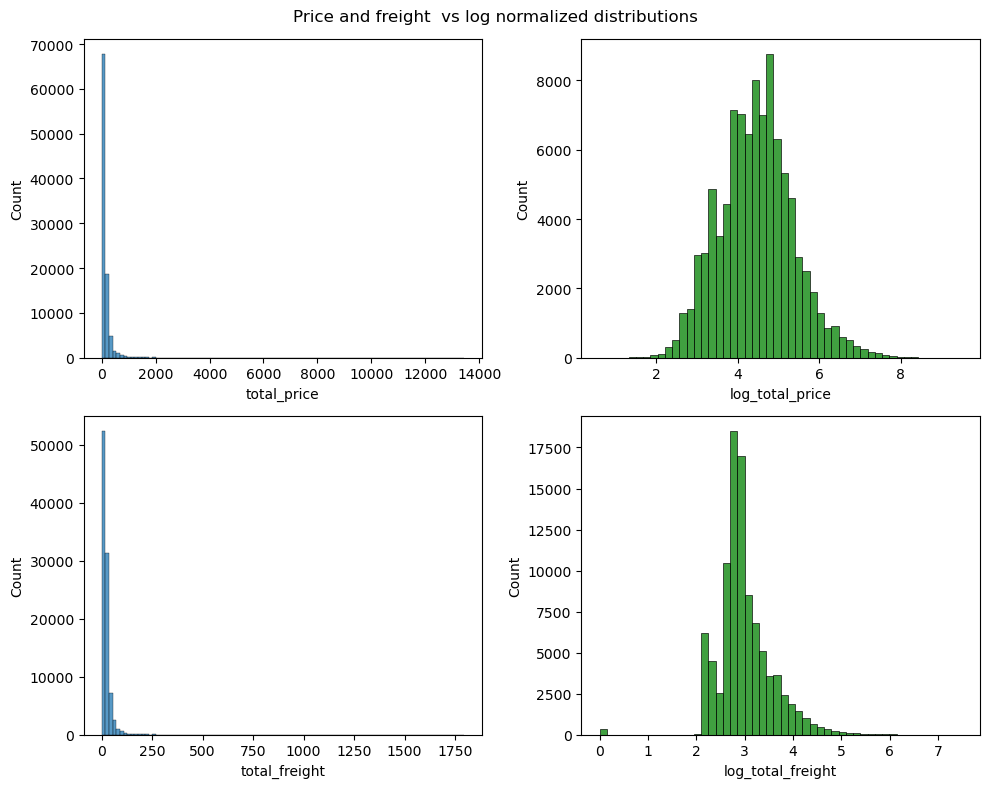

In [10]:
fig, ax = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(8)
fig.set_figwidth(10)
fig.suptitle('Price and freight  vs log normalized distributions')
sns.histplot(x=df_clean['total_price'], bins=100, ax=ax[0,0])
sns.histplot(x=df_clean['log_total_price'], bins=50, ax=ax[0,1], color='green')

sns.histplot(x=df_clean['total_freight'], bins=100, ax=ax[1,0])
sns.histplot(x=df_clean['log_total_freight'], bins=50, ax=ax[1,1], color='green')
plt.tight_layout()
plt.show()


Inspecting most popular product categories

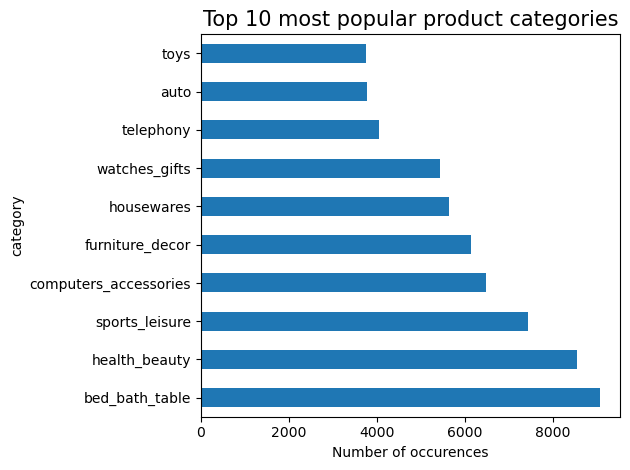

In [26]:
df_clean.groupby('category')['review_score'].count().sort_values(ascending=False)[:10].plot(kind='barh')
plt.title('Top 10 most popular product categories', size=15)
plt.xlabel('Number of occurences')
plt.tight_layout()
plt.show()

Plotting boxplots of features connected with delivery, to inspect whether there are significant outliers in their distributions

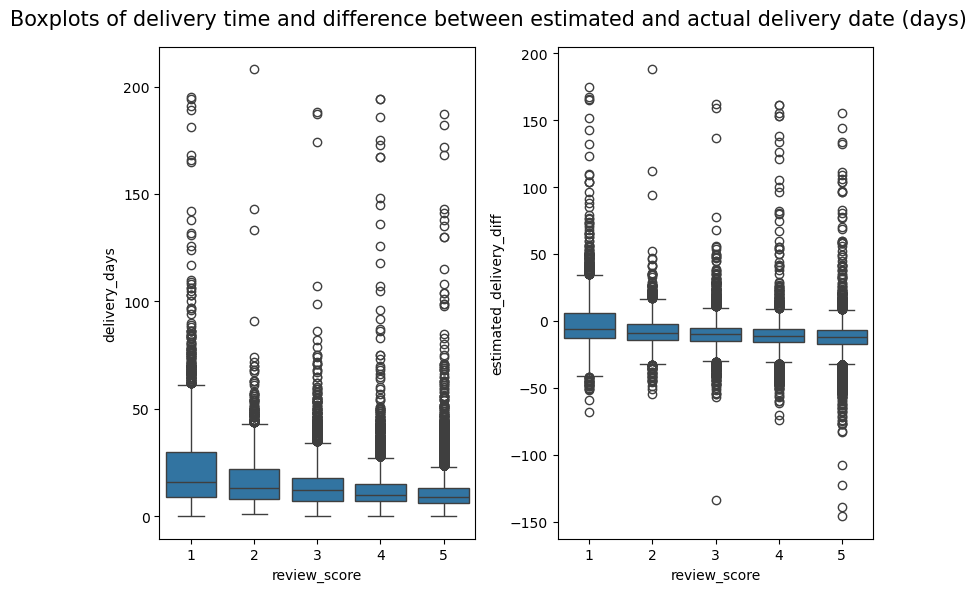

In [41]:
fig2, ax2 = plt.subplots(nrows=1, ncols=2, figsize=(8,6))
fig2.suptitle('Boxplots of delivery time and difference between estimated and actual delivery date (days)', size=15)
ax2[0] = sns.boxplot(x='review_score', y='delivery_days', data=df_clean, ax=ax2[0])
ax2[1] = sns.boxplot(x='review_score', y='estimated_delivery_diff', data=df_clean, ax=ax2[1])

plt.tight_layout()
plt.show()

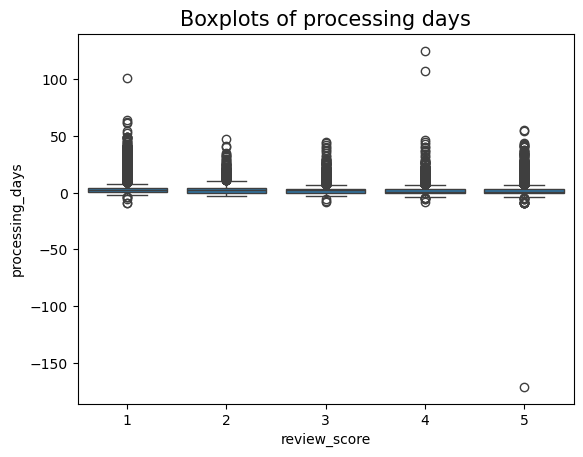

In [35]:
sns.boxplot(x='review_score', y='processing_days', data=df_clean)
plt.title('Boxplots of processing days', size=15)
plt.show()

We can see, that delivery times of orders with 5 star reviews are more clustered around the median. In contrast, 1 star reviews have wider distribution wtih longer upper whisker indicating longer wait times associated with customer dissatisfaction.

All of the displayed distributions are affected by the outliers (extreme delivery times, and differences or even some values which may be considered as anomalies) that need to be taken care of. In further steps outliers will be clipped to proper quantile values.

Processing days cannot be shorter than 0 - all the negative values are probalby results of the Olist system errors or delays connected with saving order approval dates.

In [11]:
df_clean.loc[df_clean['processing_days'] < 0 ,'processing_days'] = 0 

### Taking care of the outliers.
Calculating lower (1) and upper (99) percentiles, to set the limits and clip the outliers accordingly.

In [53]:
lower_seller = df_clean['seller_disp_diff'].quantile(0.01)
print(f'1st seller_disp_diff percentile: {lower_seller}')
print(df_clean.loc[df_clean['seller_disp_diff'] < lower_seller, 'review_score'].value_counts(normalize=True),'\n')

lower_estimated = df_clean['estimated_delivery_diff'].quantile(0.01)
print(f'1st estimated_delivery_diff percentile: {lower_estimated}')
print(df_clean.loc[df_clean['estimated_delivery_diff'] < lower_estimated, 'review_score'].value_counts(normalize=True),'\n')

1st seller_disp_diff percentile: -12.0
review_score
5    0.586885
4    0.174863
1    0.111475
3    0.090710
2    0.036066
Name: proportion, dtype: float64 

1st estimated_delivery_diff percentile: -35.0
review_score
5    0.615108
4    0.199041
1    0.082734
3    0.074341
2    0.028777
Name: proportion, dtype: float64 



In [54]:
upper_delivery = df_clean['delivery_days'].quantile(0.99)
print(f'99th delivery_days percentile: {upper_delivery}')
print(df_clean.loc[df_clean['delivery_days'] >= upper_delivery, 'review_score'].value_counts(normalize=True),'\n')

upper_estimated = df_clean['estimated_delivery_diff'].quantile(0.99)
print(f'99th estimated_delivery_diff percentile: {upper_estimated}')
print(df_clean.loc[df_clean['estimated_delivery_diff'] >= upper_estimated, 'review_score'].value_counts(normalize=True),'\n')

upper_processing = df_clean['processing_days'].quantile(0.99)
print(f'99th processing_days percentile: {upper_processing}')
print(df_clean.loc[df_clean['processing_days'] >= upper_processing, 'review_score'].value_counts(normalize=True),'\n')

upper_seller = df_clean['seller_disp_diff'].quantile(0.99)
print(f'99th seller_disp_diff percentile: {upper_seller}')
print(df_clean.loc[df_clean['seller_disp_diff'] < upper_seller, 'review_score'].value_counts(normalize=True))


99th delivery_days percentile: 45.0
review_score
1    0.690114
5    0.088403
3    0.082700
2    0.077947
4    0.060837
Name: proportion, dtype: float64 

99th estimated_delivery_diff percentile: 18.0
review_score
1    0.691073
2    0.091274
3    0.084253
5    0.076229
4    0.057172
Name: proportion, dtype: float64 

99th processing_days percentile: 16.0
review_score
1    0.408182
5    0.269091
4    0.158182
3    0.093636
2    0.070909
Name: proportion, dtype: float64 

99th seller_disp_diff percentile: 7.0
review_score
5    0.595985
4    0.197877
1    0.093843
3    0.082270
2    0.030026
Name: proportion, dtype: float64


In [55]:
df_transformed = df_clean.drop(['order_id'], axis=1).copy()

In [56]:
df_transformed['delivery_days'] = df_clean['delivery_days'].clip(upper=upper_delivery)
df_transformed['estimated_delivery_diff'] = df_clean['estimated_delivery_diff'].clip(lower = lower_estimated, upper = upper_estimated)
df_transformed['processing_days'] = df_clean['processing_days'].clip(upper = upper_processing)
df_transformed['seller_disp_diff'] = df_clean['seller_disp_diff'].clip(lower = lower_seller, upper = upper_seller)

We can see that the risk of receiving a bad review increases rapidly when order comprises more than 1 item. (from 1 to 2 items)

In [57]:
df_transformed.groupby('num_items')['bad_score'].mean()

num_items
1     0.193864
2     0.348593
3     0.388025
4     0.429158
5     0.398964
6     0.413978
7     0.590909
8     0.250000
9     0.333333
10    0.750000
11    0.750000
12    0.400000
13    1.000000
14    1.000000
15    0.000000
20    1.000000
21    1.000000
Name: bad_score, dtype: float64

Inspecting correlations between the features, and the target variable. We can see that the features connected with the delivery are moderately correlated with the target, making them good candidates for the most important model features

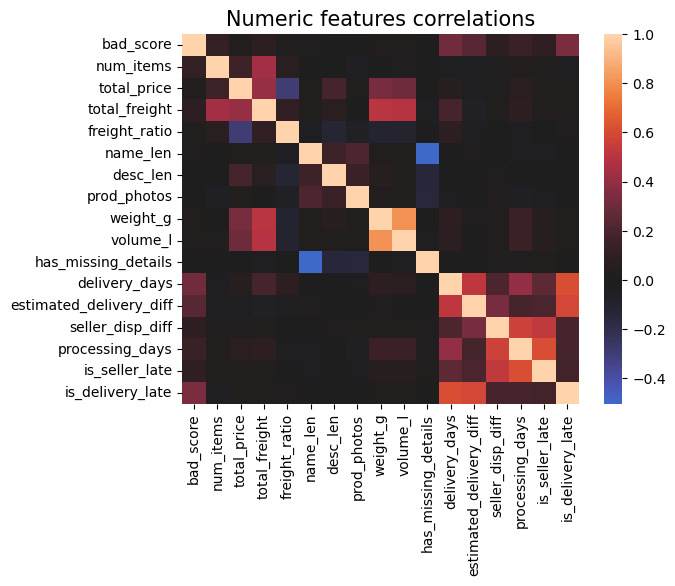

In [ ]:
sns.heatmap(df_transformed.drop(['review_score'], axis=1).corr(numeric_only=True), center= 0)
plt.show()